# Notebook 13 — Experimental Effects on Flight Kinematics

> **Supplementary §14**

This notebook uses heatmaps to visualise how experimental conditions and individual differences affect morphing flight. Each shape change mode score is represented as a row with conditions stacked for comparison.

The heatmaps are scaled to the 1st and 99th percentiles of each mode's score distribution: blue indicates negative scores, red indicates positive scores, and yellow indicates values near the mean hawk shape.

> **NOTE**: To understand what positive and negative scores mean for shape changes, use Notebook 09 to visualise each with different scores. 

These heatmaps provide a closer look at individual flight behaviour for consistent behaviours. As within- and across-individual variation is high, they do not represent stereotyped generalisable behaviours. Different analytical approaches would be required for quantitative comparison across individuals with variable wingbeat frequencies.


## Contents
1. [Setup and data loading](#setup)
2. [Heatmap comparisons — obstacle flights](#obstacle-heatmaps)
3. [Heatmap comparisons — weight effect](#weight-heatmaps)
4. [Heatmap comparisons — naive vs experienced](#naive-heatmaps)
5. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from morphing_birds import Animal3D, animate_plotly

from kinematic_morphospace import (
    filter_by, run_PCA, apply_sign_conventions,
    get_score_df, get_score_range, prepare_heatmap_mode_order,
    reconstruct, to_bilateral,
)
from kinematic_morphospace.plotting import (
    save_figure,
    prepare_heatmap_comparison, plot_difference_PC_scores_heatmap,
    plot_difference_exp_scores_heatmap,
)

CONFIG = {
    "bin_size": 0.07,
    "fig_dir": Path("../../figures/supplementary"),
}

## Load Data and Prepare Scores

In [2]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=CONFIG["bin_size"])
PC_cols = prepare_heatmap_mode_order(scores_df)

print(f"Total frames: {scores.shape[0]:,}")
print(f"Scores dataframe: {scores_df.shape}")
print(f"Mode order: {PC_cols}")

  Sign conventions applied: PC07 negated (positive = m-folded)
Total frames: 289,528
Scores dataframe: (289528, 27)
Mode order: ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC08', 'PC06', 'PC07', 'PC09']


### Checking sign conventions with animation

The sign conventions for each mode (e.g. PC07 negated so positive = m-folded) are applied automatically by `get_score_df` for heatmaps. The animation below uses raw scores for reconstruction (so the 3D shape is correct) and applies sign conventions only to the slider labels (so the displayed values match the heatmaps). Use this to verify what positive and negative scores look like for any mode.

In [3]:
colour_list = ['#B5E675', '#6ED8A9', '#51B3D4',
               '#4579AA', '#F19EBA', '#BC96C9',
               '#917AC2', '#BE607F', '#624E8B',
               '#888888', '#888888', '#888888']

mu = np.load("../../data/unilateral/mean_shape.npy").reshape(1, -1, 3)
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')

def animate_mode(pc_number, num_frames=25):
    """Animate a single morphing mode as a bilateral hawk shape.
    
    Raw scores are used for reconstruction (so the 3D shape is correct).
    Sign conventions are applied only to the slider labels (so the
    displayed values match the heatmap convention).
    """
    # Raw scores for reconstruction — shape is mathematically correct
    score_frames = get_score_range(scores, num_frames=num_frames)
    component_index = [pc_number - 1]
    reconstructed = reconstruct(score_frames, principal_components, mu, component_index)
    recon_bilateral = to_bilateral(reconstructed)

    # Apply sign conventions only to the slider labels
    slider_scores = apply_sign_conventions(score_frames, verbose=False)[:, pc_number - 1]

    fig = animate_plotly(hawk3d, recon_bilateral, colour=colour_list[pc_number - 1],
                         score_vals=slider_scores)
    fig.show()

# Change the mode number to check any mode (1–9)
animate_mode(7)

## Heatmap Comparisons — Obstacle Flights

Comparing control and obstacle flights for individual hawks. The upper row of each heatmap shows the obstacle condition; the lower row shows the control. The vertical line indicates the obstacle position (−4.5 m from the landing perch). Flights with added weight (IMU) are excluded.

### Colour interpretation

The heatmaps are scaled to the 1st and 99th percentiles of each morphing mode's score distribution:
- **Blue** — negative scores (e.g., wings lowered, contracted, or swept back relative to the mean)
- **Red** — positive scores (e.g., wings raised, spread, or swept forward relative to the mean)
- **Yellow** — values near the mean hawk shape

Condition 1: Number of frames: 18092; Number of flights: 50
Condition 2: Number of frames: 7896; Number of flights: 33
--- Toothless ---


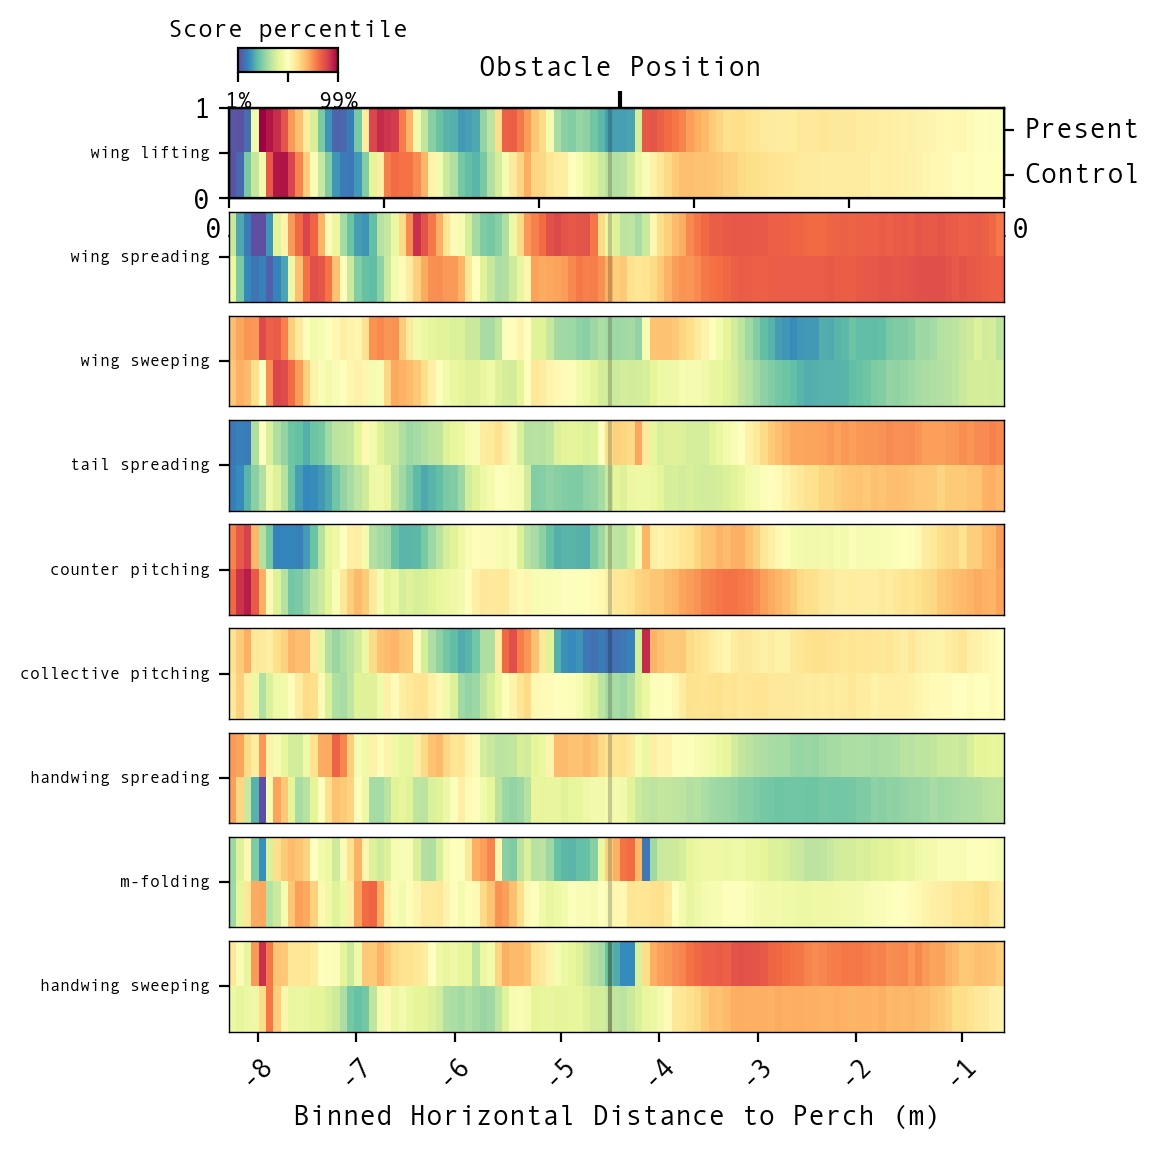

Saved: ../../figures/supplementary/S14_obstacle_Toothless.pdf
Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4998; Number of flights: 32
--- Ruby ---


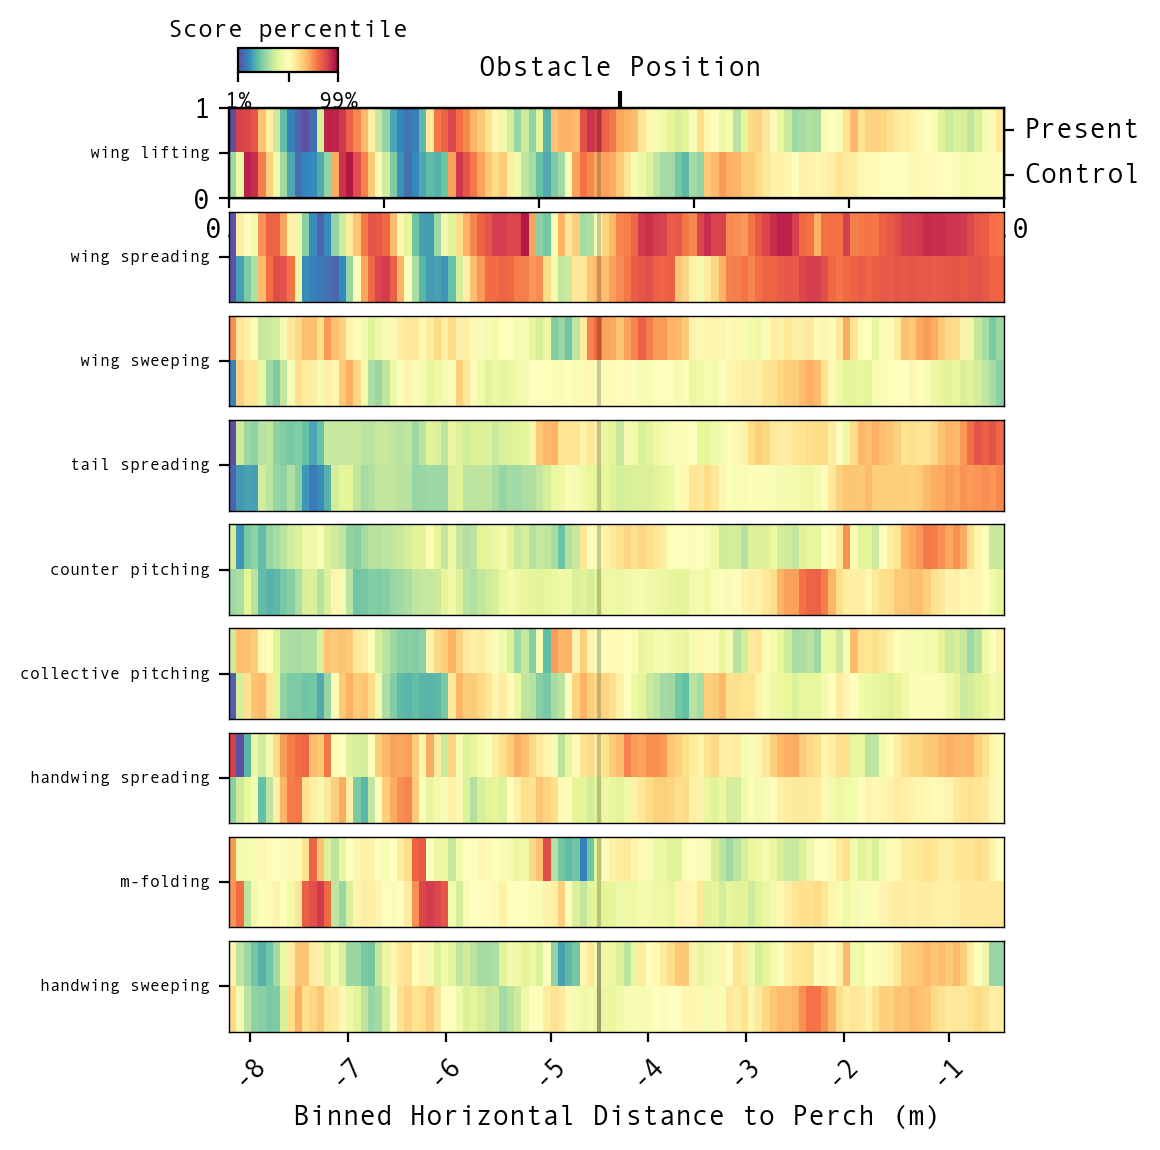

Saved: ../../figures/supplementary/S14_obstacle_Ruby.pdf


In [4]:
plt.close("all")
hawks = ["Toothless", "Ruby"]

for hawk in hawks:
    control_df, obstacle_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
        condition2={"obstacle": 1, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk} ---")
    ax = plot_difference_PC_scores_heatmap(control_df, obstacle_df, PC_cols, score_5, score_95)
    save_figure(ax, CONFIG["fig_dir"] / f"S14_obstacle_{hawk}.pdf")

The obstacle triggers both a localised span-reduction and a broader postural shift, visible in the lower-order morphing modes:

- **Wing spreading (PC02)** shows a negative dip at 6.5–4.5 m in both hawks (Toothless −0.017, Ruby −0.036) — wings fold in the flapping phase immediately before the obstacle, then recover afterwards. This is a span-reduction manoeuvre for gap negotiation.
- **Handwing spreading (PC06)** increases in both hawks across all distance bins (+0.003 to +0.010), suggesting the handwing spreads further to maintain control authority while overall span is reduced.
- **Tail spreading (PC04)** is consistently positive in Toothless across all bins (+0.007 to +0.015), with a weaker signal in Ruby. The tail spreads and minor wing sweep back during obstacle flights.
- **M-folding (PC07)** shifts negative (toward w-folding) in both hawks across all bins — not just at the obstacle. This suggests a globally altered wing configuration in obstacle flights rather than a purely localised adjustment.

The response is qualitatively similar between hawks — the same modes are recruited — but differs in magnitude. Ruby shows a stronger PC02 (wing folding) response; Toothless shows a stronger PC04 (tail spreading) response.

## Heatmap Comparisons — Weight Effect

Comparing flights with and without an added weight (IMU) for individual hawks. The upper row shows the weighted condition; the lower row shows the control.

Condition 1: Number of frames: 8906; Number of flights: 45
Condition 2: Number of frames: 2750; Number of flights: 16
--- Charmander: weight vs control ---


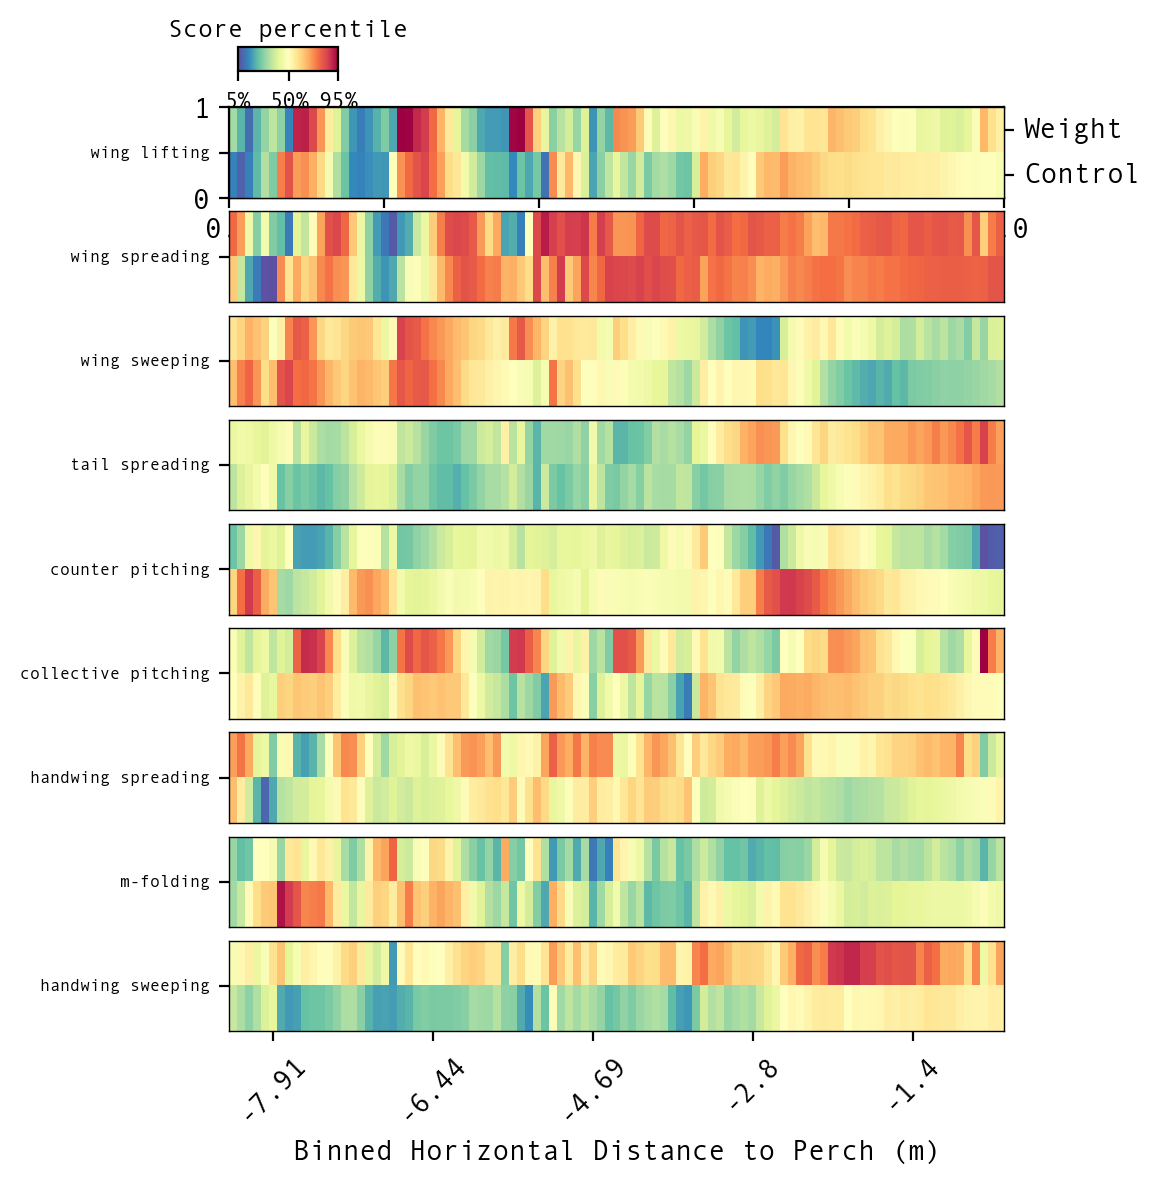

Saved: ../../figures/supplementary/S14_weight_Charmander.pdf
Condition 1: Number of frames: 11136; Number of flights: 48
Condition 2: Number of frames: 4394; Number of flights: 18
--- Ruby: weight vs control ---


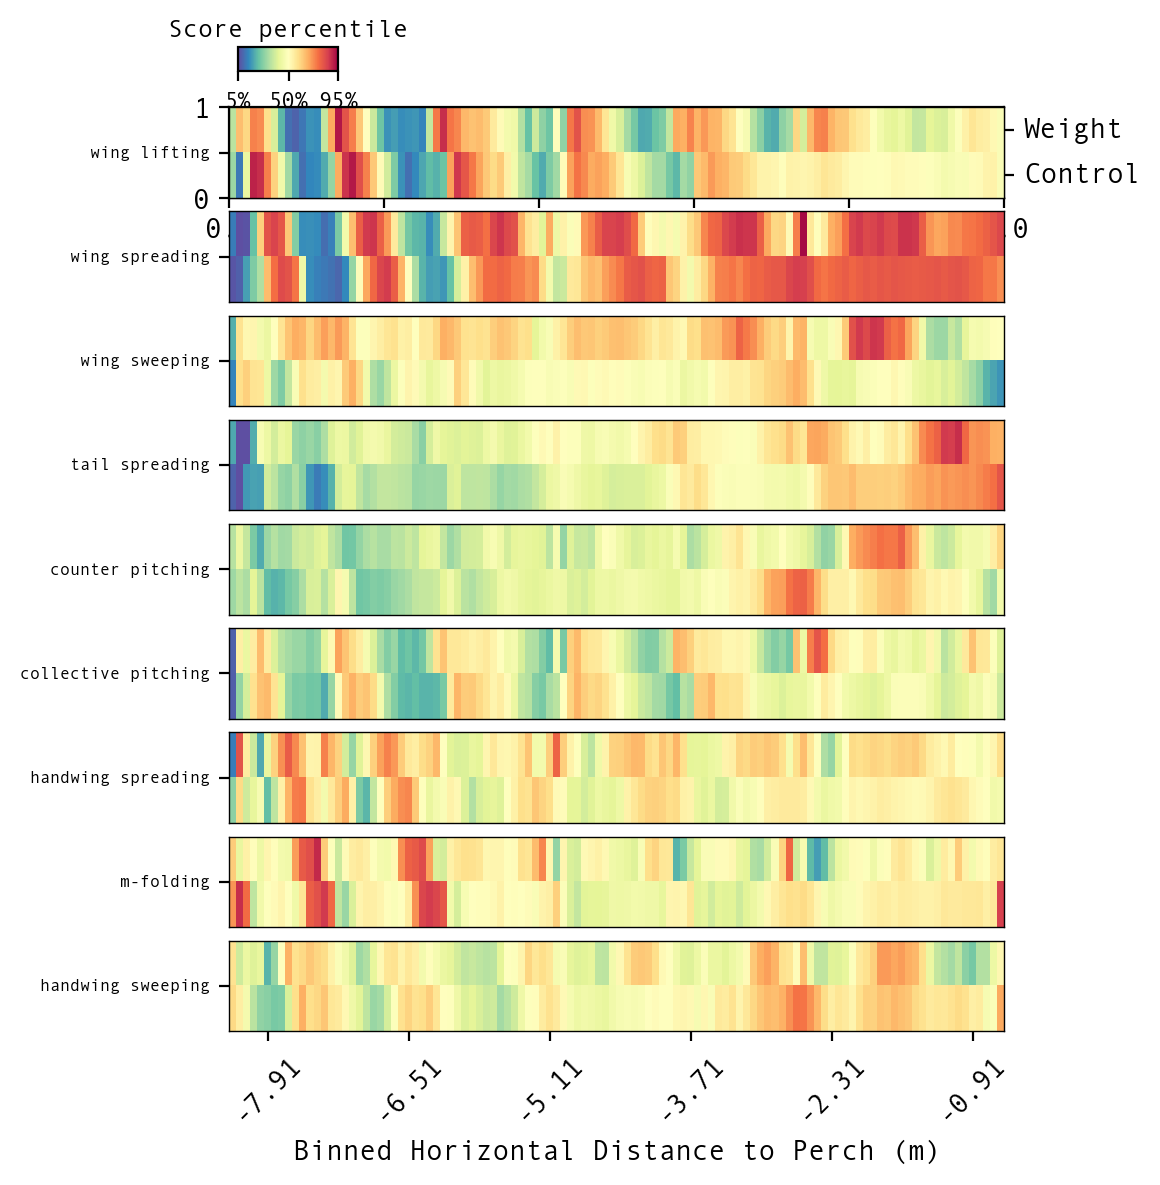

Saved: ../../figures/supplementary/S14_weight_Ruby.pdf


In [5]:
plt.close("all")
hawks = ["Charmander", "Ruby"]

for hawk in hawks:
    control_df, weight_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk, "year": 2020},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 0, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "IMU": 1, "hawkname": hawk},
    )
    print(f"--- {hawk}: weight vs control ---")
    ax = plot_difference_exp_scores_heatmap(
        control_df, "Control", weight_df, "Weight", PC_cols, score_5, score_95
    )
    save_figure(ax, CONFIG["fig_dir"] / f"S14_weight_{hawk}.pdf")

The weight effect is subtle but shows consistent cross-hawk patterns in the lower-order modes:

- **Wing sweeping (PC03)** shifts positive (wings swept forwards) in both hawks, strongest near landing (Ruby +0.027 at 2.5–0.5 m). Forward sweep under load is consistent with shifting the centre of pressure to compensate for the added dorsal mass.
- **M-folding (PC07)** shifts negative (toward w-folding) in most bins for both hawks, as it does in the obstacle comparison. This may be a general aerodynamic load-compensation response.
- **Counter pitching (PC05)** is weakly negative in both hawks — the leading edge pitches down under weight. This is consistent with the added mass pulling the leading edge down, though the magnitudes are small (≤0.024).

The weight effects are smaller than the obstacle effects (largest ~0.03 vs ~0.04) and the weighted condition has fewer flights, so these patterns are suggestive rather than definitive. The most robust finding is the forward wing sweep (PC03), which is consistent across hawks and distance bins.

## Heatmap Comparisons — Naive vs Experienced

Two hawks (Drogon, Toothless) were recorded as both naive juveniles (2017) and experienced adults (2020). The comparison reveals how flight morphing patterns change with experience.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 7312; Number of flights: 46
--- Drogon: naive vs experienced ---


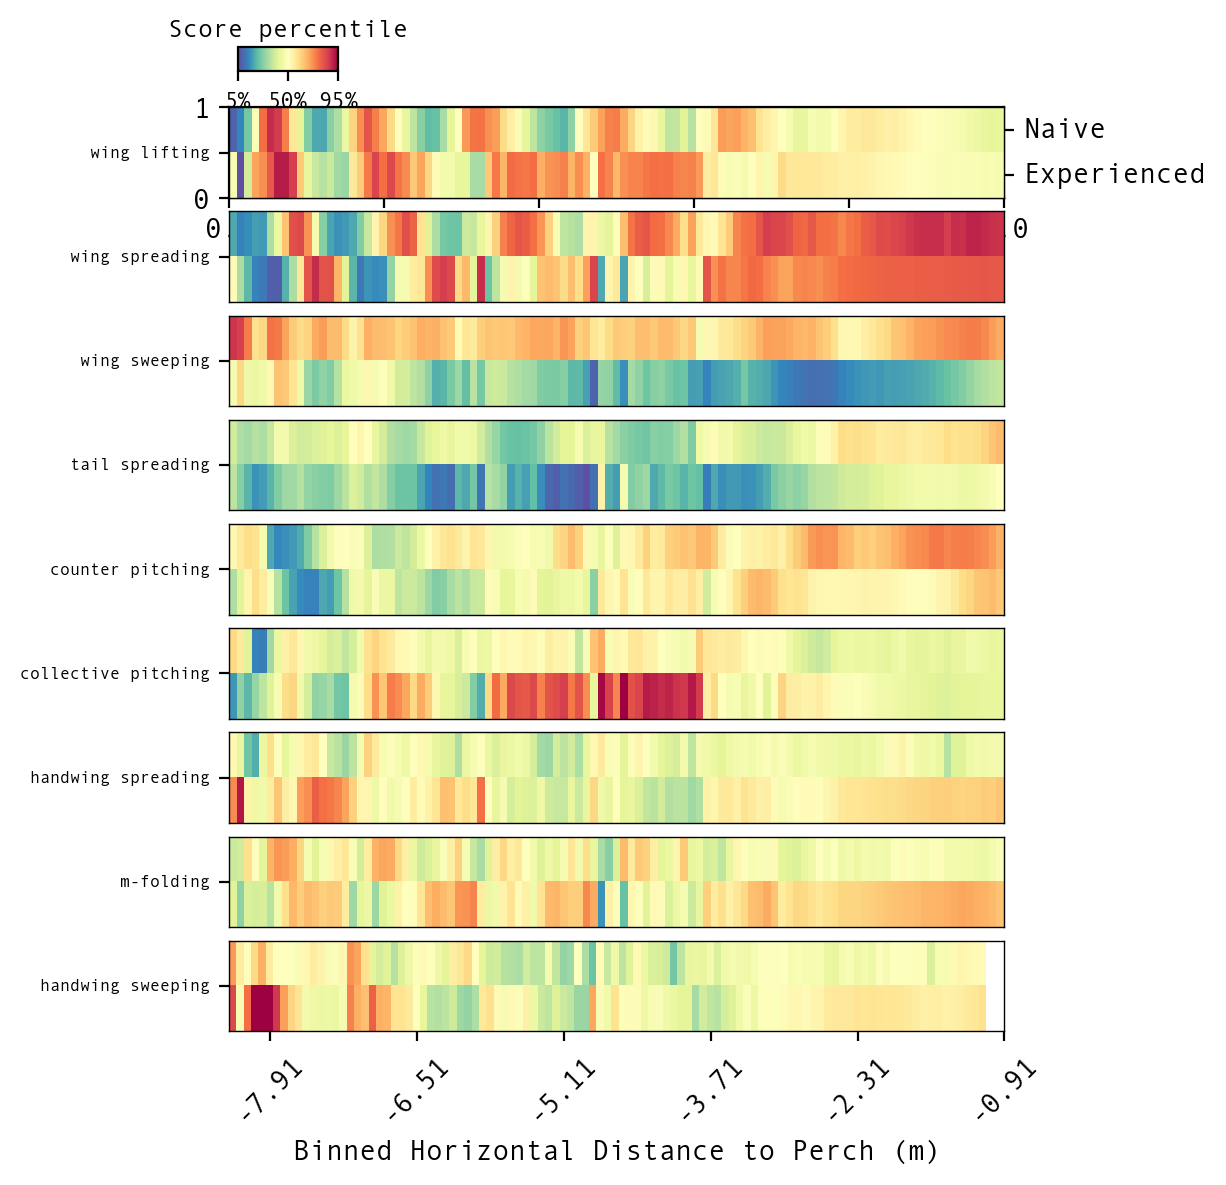

Saved: ../../figures/supplementary/S14_experience_Drogon.pdf
Condition 1: Number of frames: 14778; Number of flights: 58
Condition 2: Number of frames: 18092; Number of flights: 50
--- Toothless: naive vs experienced ---


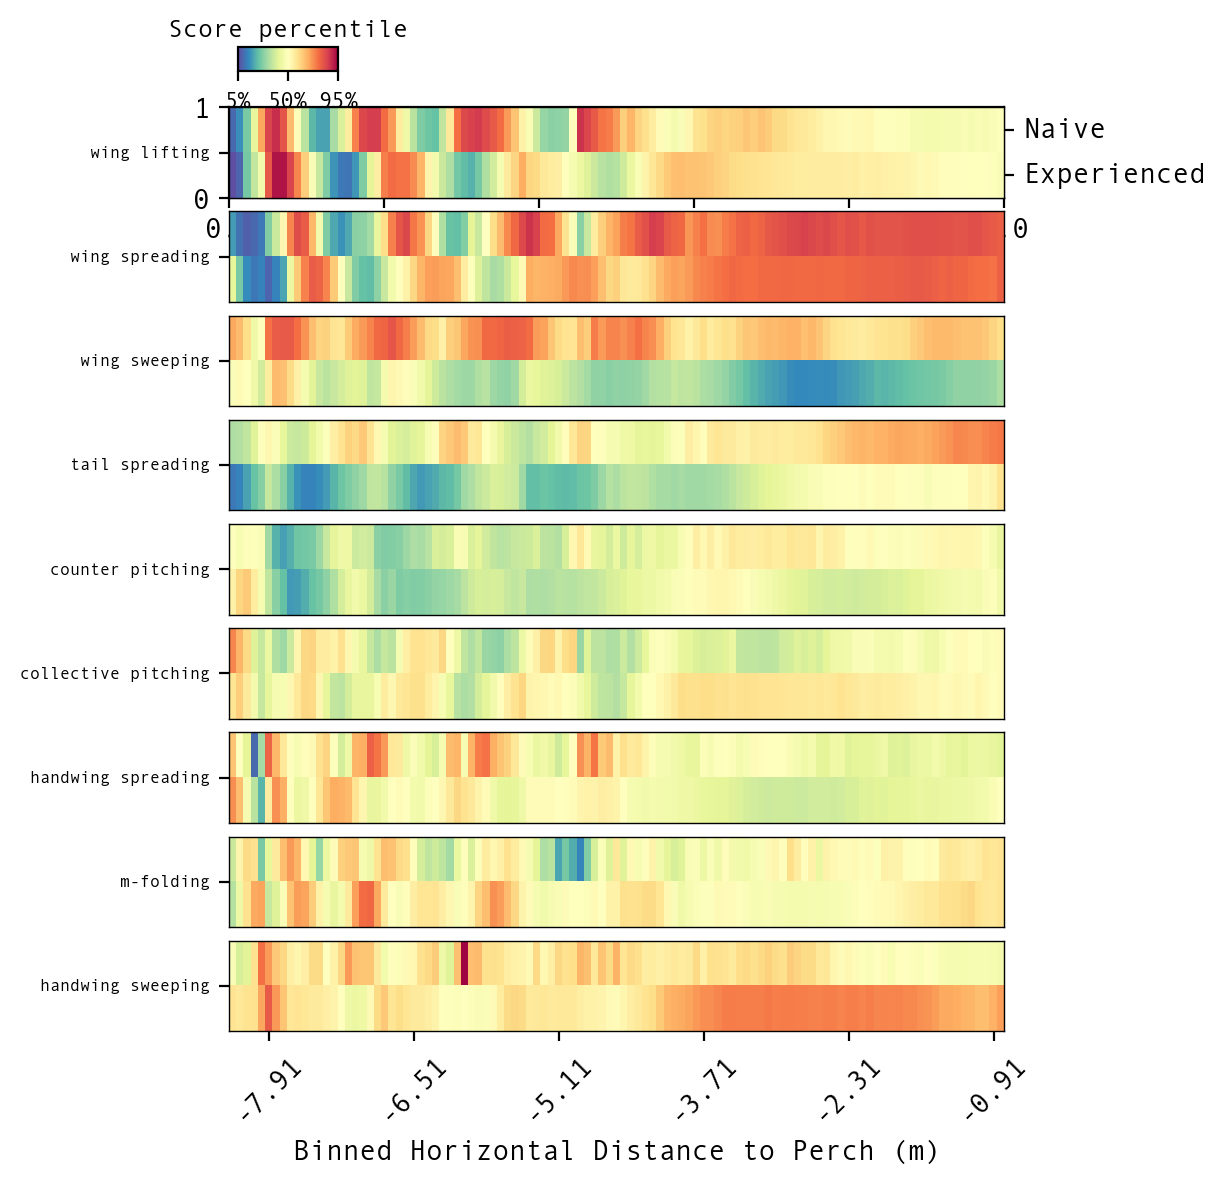

Saved: ../../figures/supplementary/S14_experience_Toothless.pdf


In [6]:
plt.close("all")
naive_hawks = ["Drogon", "Toothless"]

for hawk in naive_hawks:
    naive_df, exp_df, score_5, score_95 = prepare_heatmap_comparison(
        scores_df,
        reference_filters={"hawkname": hawk},
        condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": hawk},
        condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": hawk, "IMU": 0},
    )
    print(f"--- {hawk}: naive vs experienced ---")
    ax = plot_difference_exp_scores_heatmap(
        exp_df, "Experienced", naive_df, "Naive", PC_cols, score_5, score_95
    )
    save_figure(ax, CONFIG["fig_dir"] / f"S14_experience_{hawk}.pdf")

The experience effect produces the largest and most consistent shifts of any comparison in this notebook, with magnitudes 3–5× larger than the obstacle or weight effects:

- **Wing sweeping (PC03)** is the clearest signal: experienced hawks sweep their wings markedly backwards across the entire approach. Drogon: −0.05 to −0.11; Toothless: −0.05 to −0.08. The naive juveniles held their wings near neutral or slightly forward-swept; the experienced adults adopt a consistently backward-swept posture.
- **Tail spreading (PC04)** decreases with experience in both hawks across all bins (−0.02 to −0.05). Experienced birds contract the tail and bring it forward.
- **Wing spreading (PC02)** is negative in 3 of 4 bins for both hawks, indicating a more folded wing posture with experience.
- **Collective pitching (PC08)** shifts positive in most bins for both hawks, indicating a trailing-edge-up pitch adjustment.

Together, the backward wing sweep (PC03), wing folding (PC02), and tail contraction (PC04) describe a more retracted, streamlined flight profile in experienced adults. This is consistent with experienced hawks maintaining higher approach speeds and braking later — a precision approach strategy replacing the cautious, spread-wing posture of naive juveniles.

## Heatmap Comparisons — Drogon vs Rhaegal (Naive)

Drogon and Rhaegal are brothers, both recorded as naive juveniles (2017). Comparing their morphing patterns reveals individual differences in flight style at a similar developmental stage.

Condition 1: Number of frames: 14550; Number of flights: 76
Condition 2: Number of frames: 28392; Number of flights: 114
--- Drogon vs Rhaegal (both naive) ---


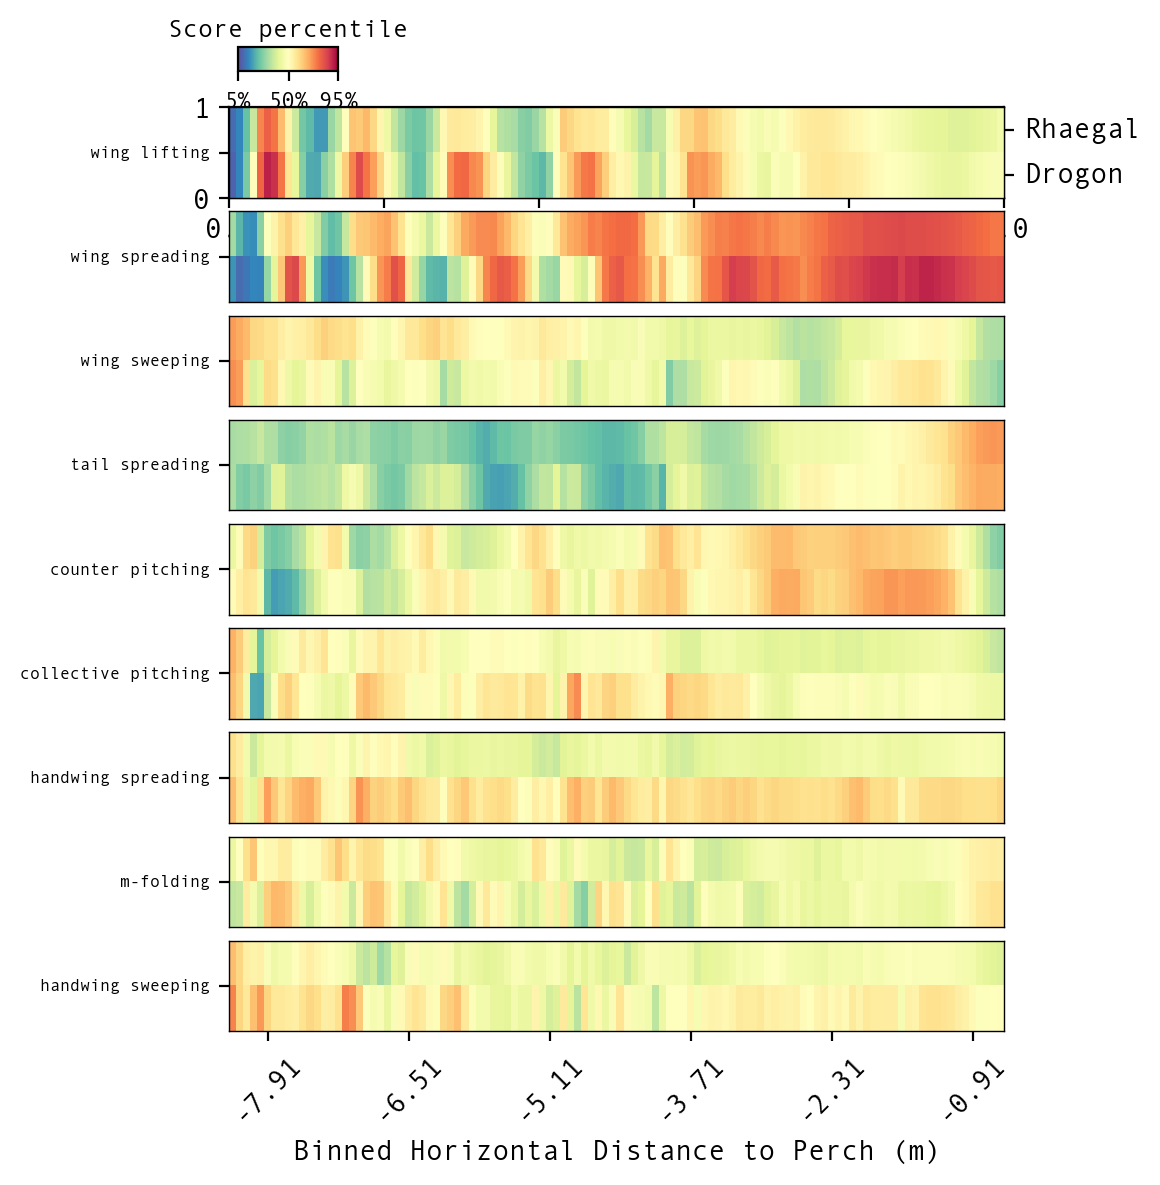

Saved: ../../figures/supplementary/S14_siblings_Drogon_Rhaegal.pdf


In [7]:
plt.close("all")

drogon_df, rhaegal_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2017},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Drogon"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2017, "hawkname": "Rhaegal"},
)
print("--- Drogon vs Rhaegal (both naive) ---")
ax = plot_difference_exp_scores_heatmap(
    drogon_df, "Drogon", rhaegal_df, "Rhaegal", PC_cols, score_5, score_95
)
save_figure(ax, CONFIG["fig_dir"] / "S14_siblings_Drogon_Rhaegal.pdf")

Condition 1: Number of frames: 23456; Number of flights: 67
Condition 2: Number of frames: 15530; Number of flights: 66
--- Toothless vs Ruby (both experienced) ---


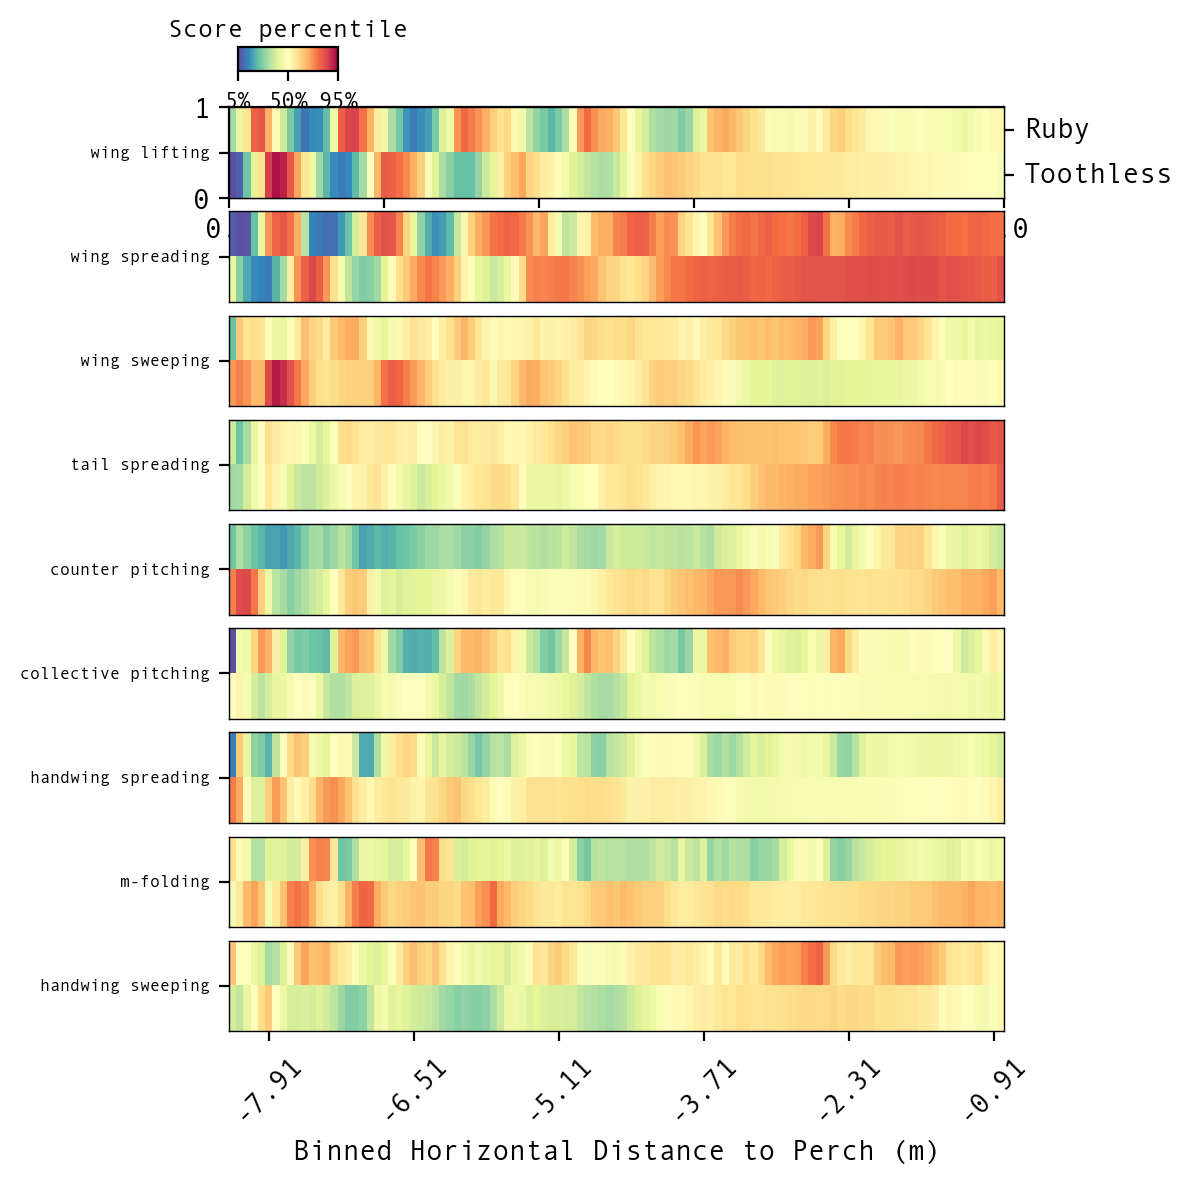

Saved: ../../figures/supplementary/S14_individuals_Toothless_Ruby.pdf


In [8]:
plt.close("all")

toothless_df, ruby_df, score_5, score_95 = prepare_heatmap_comparison(
    scores_df,
    reference_filters={"year": 2020},
    condition1={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Toothless"},
    condition2={"obstacle": 0, "perchDist": 9, "year": 2020, "hawkname": "Ruby"},
)
print("--- Toothless vs Ruby (both experienced) ---")
ax = plot_difference_exp_scores_heatmap(
    toothless_df, "Toothless", ruby_df, "Ruby", PC_cols, score_5, score_95
)
save_figure(ax, CONFIG["fig_dir"] / "S14_individuals_Toothless_Ruby.pdf")

The individual comparisons reveal which morphing modes carry individual signatures — consistent differences that persist across the full approach rather than varying with distance:

**Siblings (Drogon vs Rhaegal, both naive 2017):**
- **Handwing spreading (PC06)** is the clearest sibling difference: Rhaegal consistently more contracted across all bins (~−0.02). This is a stable individual signature, not distance-dependent.
- **Wing spreading (PC02)** differs in early flight (Rhaegal more spread at 8.5–4.5 m) but reverses near landing — this is a distance-phased difference rather than a stable signature.

**Experienced individuals (Toothless vs Ruby, both 2020):**
- **M-folding (PC07)** is the cleanest individual signature in the dataset: Ruby shows consistently more w-folding across all bins (~−0.019), with strikingly uniform magnitude.
- **Counter pitching (PC05)** is consistently more negative in Ruby across all bins (−0.013 to −0.026): Ruby flies with the leading edge pitched further down.
- **Tail spreading (PC04)** is consistently more positive in Ruby across all bins — Ruby spreads the tail more.

The modes that distinguish individuals — PC05, PC06, PC07 — are the finer geometric adjustments: handwing conformation, chordwise camber, and pitching trim. These likely reflect individual morphology or habitual motor strategies rather than task demands. By contrast, the task-driven modes (PC02, PC03) vary strongly with distance but not consistently between individuals.

## Summary

The heatmaps reveal how experimental conditions and individual identity affect morphing patterns across the lower-order shape modes:

- **Obstacle flights** trigger a localised span-reduction (PC02 wing folding at the obstacle) alongside a broader postural shift: increased handwing spread (PC06), tail spreading (PC04), and a shift toward w-folding (PC07) across the full approach. The same modes are recruited in both hawks, but their relative magnitudes differ.
- **Added weight** produces a subtle but consistent forward wing sweep (PC03) in both hawks, strongest near landing. M-folding (PC07) also shifts toward w-folding, as in the obstacle comparison — suggesting a shared aerodynamic load-compensation mechanism. Weight effects are smaller than obstacle effects and should be treated as suggestive given lower sample sizes.
- **Experience** produces the largest shifts — 3–5× the magnitude of obstacle or weight effects. Experienced adults sweep their wings markedly backwards (PC03), contract their tails (PC04), and adopt a more folded wing posture (PC02) across the entire approach. This describes a retracted, streamlined flight profile consistent with higher approach speeds and later braking.
- **Individual signatures** emerge most clearly in the finer geometric modes: handwing spreading (PC06) distinguishes siblings, while m-folding (PC07) and counter pitching (PC05) distinguish experienced individuals. These modes are uniform across distance bins, suggesting they reflect individual morphology or habitual motor strategies rather than task demands.

| Comparison | Dominant modes | Effect size | Spatial pattern |
|---|---|---|---|
| Obstacle | PC02, PC04, PC06, PC07 | Moderate (~0.02–0.04) | PC02 localised at obstacle; others global |
| Weight | PC03, PC07, PC05 | Small (~0.01–0.03) | Global, strongest near landing |
| Experience | PC03, PC04, PC02, PC08 | Large (~0.05–0.11) | Global across full approach |
| Individual | PC05, PC06, PC07 | Moderate (~0.02) | Uniform — distance-independent |

> **Caveat (per §14):** These heatmaps provide a closer look at individual flight behaviour for consistent behaviours. As within- and across-individual variation is high, the heatmaps do not represent stereotyped generalisable behaviours and are not useful for comparison with highly variable flights. More advanced methods would be required to account for variable wingbeat frequencies and to compare rigorously across individuals.

---

## References

- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.